# Biseting


In [1]:
import sklearn
import numpy as np
import os
import copy

np.random.seed(42)


import matplotlib as mpl
from sklearn.metrics import pairwise_distances
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "biset"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

n_init = 10

def save_fig(fig_id, tight_layout=True, fig_extension="pdf", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Generate


In [2]:
from sklearn.datasets import make_blobs

blob_centers = np.array(
    [[ 0.2,  2.3],
     [-1.5 ,  2.3],
     [-2.8,  1.8],
     [-2.8,  2.8],
     [-2.8,  1.3],
     [-0.5,  1.5]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1, 0.15])

X, y = make_blobs(n_samples=3000, centers=blob_centers,
                  cluster_std=blob_std, random_state=7)

In [3]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [4]:
def plot_color_clusters(X, y, center):
    unique_labels = np.unique(y)

    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    plot_centroids(center)
    for label, color in zip(unique_labels, colors):
        class_points = X[y == label]
        plt.scatter(class_points[:, 0], class_points[:, 1], color=color, label=f'Cluster {label}')

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$', rotation=0)
    #plt.title('Clustered Data')


Saving figure blobs_diagram


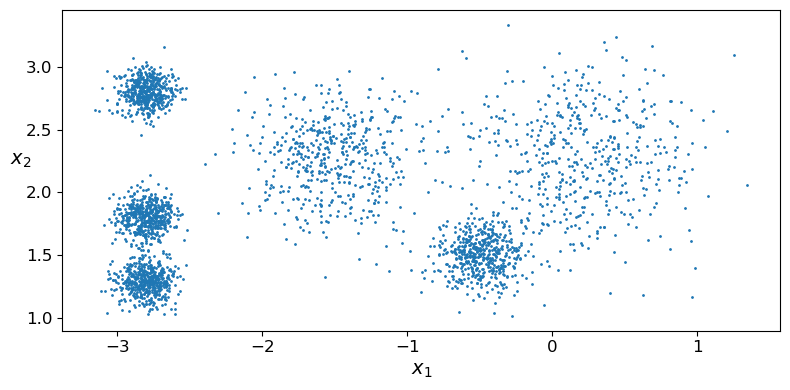

In [5]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
save_fig("blobs_diagram")
plt.show()

Saving figure 2dKDE


C:\Users\dell\AppData\Local\Temp\ipykernel_17208\168220867.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


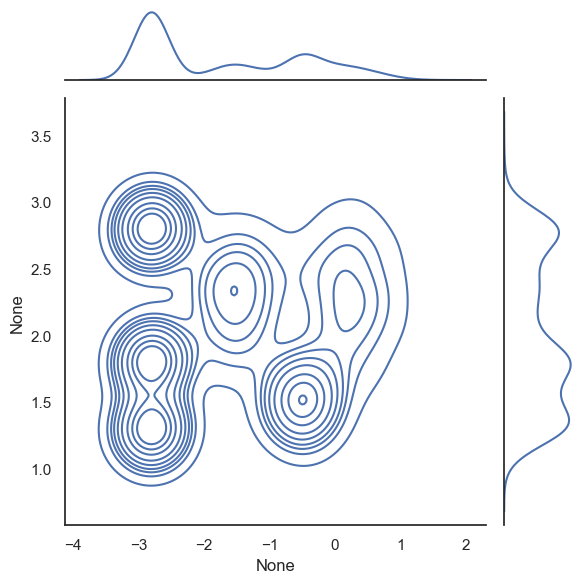

In [6]:
x_coords = [coord[0] for coord in X]
y_coords = [coord[1] for coord in X]

sns.set(style="white", color_codes=True)
g = sns.jointplot(x=x_coords, y=y_coords, kind="kde", space=0, color="b")
save_fig("2dKDE")
plt.show()

# Fit and Predict


In [7]:
from sklearn.cluster import KMeans,BisectingKMeans

In [8]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=1, n_init=n_init)
y_pred = kmeans.fit_predict(X)
bi_kmeans = BisectingKMeans(n_clusters=k, random_state=1, n_init=n_init)
y_bi_pred = bi_kmeans.fit_predict(X)

In [9]:
print(y_pred)
print(y_bi_pred)

[3 5 3 ... 1 3 0]
[4 0 4 ... 5 4 1]


In [10]:
print(kmeans.cluster_centers_)
print(bi_kmeans.cluster_centers_)

[[-2.79448454  2.79734389]
 [-0.47391229  1.52612548]
 [-2.79695183  1.80602402]
 [-1.50412048  2.28635375]
 [ 0.25088801  2.33966613]
 [-2.799667    1.29156584]]
[[-2.77794655  1.55293821]
 [-2.80067077  2.79893437]
 [-1.7241521   2.3272208 ]
 [ 0.26609887  2.31107499]
 [-1.21298002  2.29340265]
 [-0.48633857  1.51840775]]


In [11]:
print(kmeans.labels_)
print(bi_kmeans.labels_)

[3 5 3 ... 1 3 0]
[4 0 4 ... 5 4 1]


# Decision Boundaries


In [12]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=5, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True, show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

def plot_similarity_matrix(clusterer, X, n_samples=100, cmap="YlGnBu"):
    # Randomly select a subset of samples
    random_indices = np.random.choice(X.shape[0], n_samples, replace=False)
    sampled_X = X[random_indices]

    # Use the provided clusterer to predict labels
    labels = clusterer.predict(sampled_X)

    # Compute the similarity matrix
    similarity_matrix = 1 - pairwise_distances(sampled_X, metric='euclidean') / np.max(pairwise_distances(sampled_X, metric='euclidean'))

    # Sort the samples based on cluster labels
    order = np.argsort(labels)
    similarity_matrix = similarity_matrix[order][:, order]

    # Plot the similarity matrix using Seaborn heatmap
    sns.set(font_scale=1.2)
    plt.figure(figsize=(8, 8))
    sns.heatmap(similarity_matrix, cmap=cmap, square=True, cbar=False)

    plt.title("Similarity Matrix Heatmap (Clustered Data)")

In [13]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

Saving figure voronoi_diagram


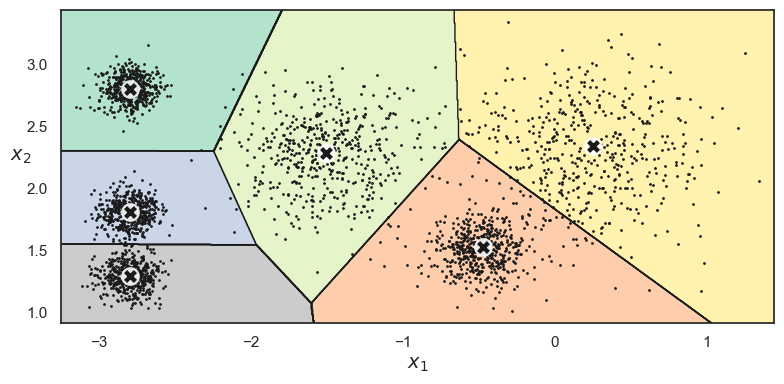

In [14]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_diagram")
plt.show()

Saving figure biset_voronoi_diagram


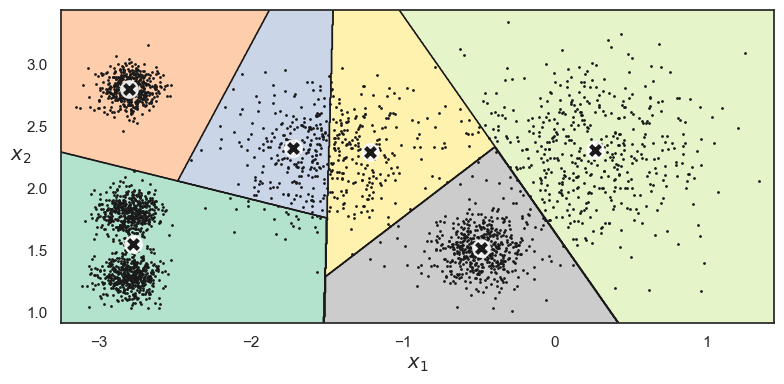

In [15]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(bi_kmeans, X)
save_fig("biset_voronoi_diagram")
plt.show()

Saving figure color_scatter


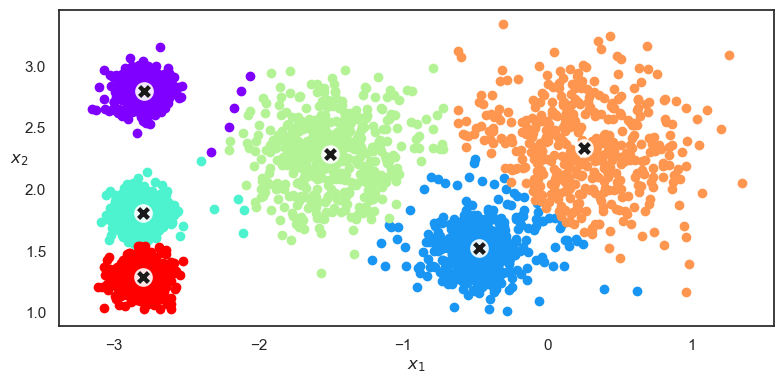

In [16]:
plt.figure(figsize=(8, 4))
plot_color_clusters(X, kmeans.labels_, kmeans.cluster_centers_)
save_fig("color_scatter")
plt.show()

Saving figure biset color_scatter


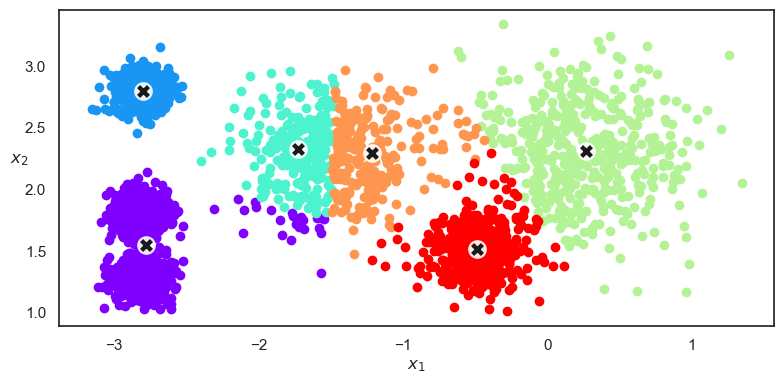

In [17]:
plt.figure(figsize=(8, 4))
plot_color_clusters(X, bi_kmeans.labels_, bi_kmeans.cluster_centers_)
save_fig("biset color_scatter")
plt.show()

Saving figure Similarity Matrix Heatmap


<Figure size 800x400 with 0 Axes>

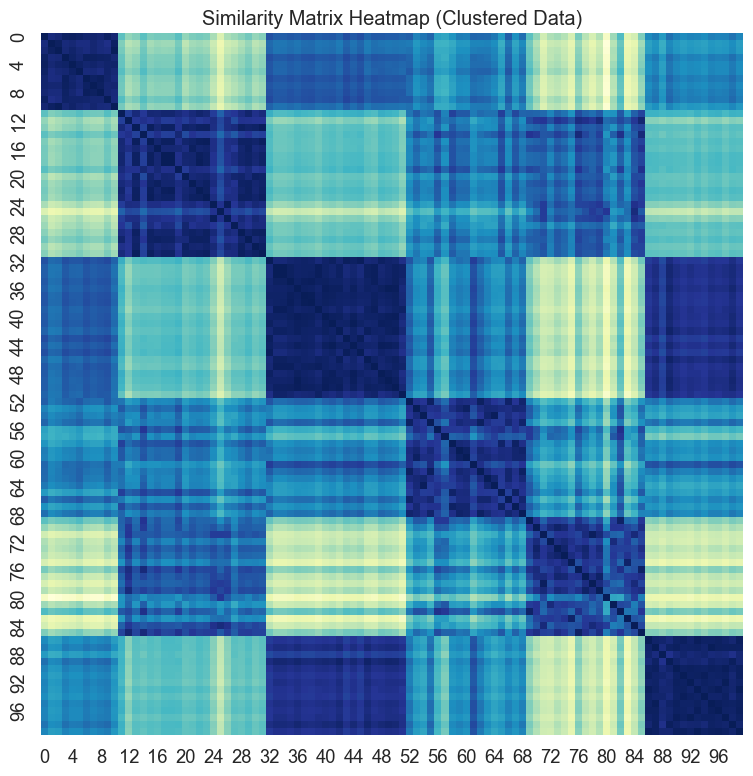

In [18]:
plt.figure(figsize=(8, 4))
plot_similarity_matrix(kmeans, X)
save_fig('Similarity Matrix Heatmap')
plt.show()

Saving figure Biseting Similarity Matrix Heatmap


<Figure size 800x400 with 0 Axes>

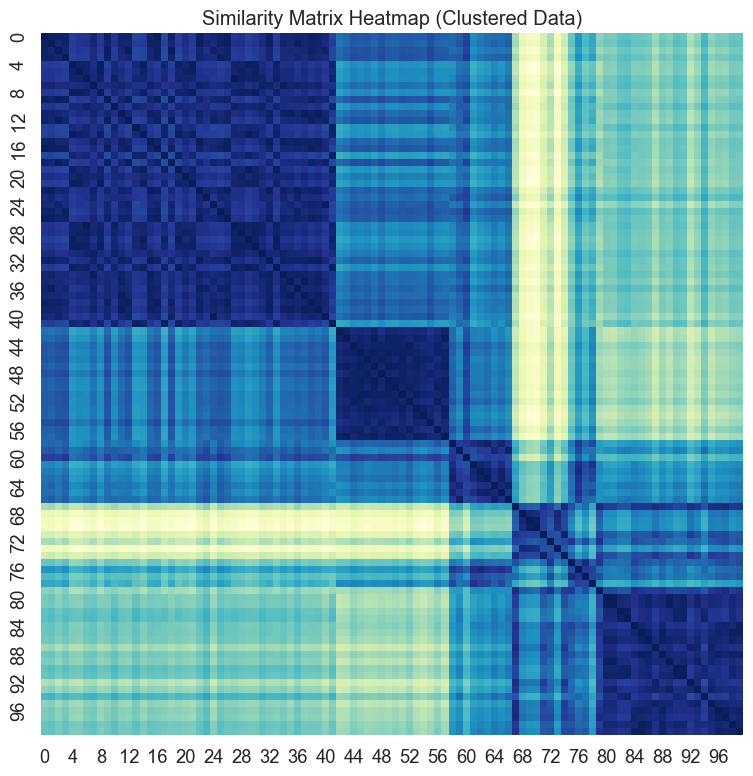

In [19]:
plt.figure(figsize=(8, 4))
plot_similarity_matrix(bi_kmeans, X)
save_fig('Biseting Similarity Matrix Heatmap')
plt.show()

In [20]:
bisect_kmeans_iter1 = BisectingKMeans(n_clusters=1, n_init=1, max_iter=1,random_state=1)
bisect_kmeans_iter2 = BisectingKMeans(n_clusters=2, n_init=1, max_iter=1,random_state=1)
bisect_kmeans_iter3 = BisectingKMeans(n_clusters=3, n_init=1, max_iter=1,random_state=1)
bisect_kmeans_iter4 = BisectingKMeans(n_clusters=4, n_init=1, max_iter=1,random_state=1)
bisect_kmeans_iter5 = BisectingKMeans(n_clusters=5, n_init=1, max_iter=1,random_state=1)
bisect_kmeans_iter6 = BisectingKMeans(n_clusters=6, n_init=1, max_iter=1,random_state=1)

bisect_kmeans_iter1.fit(X)
bisect_kmeans_iter2.fit(X)
bisect_kmeans_iter3.fit(X)
bisect_kmeans_iter4.fit(X)
bisect_kmeans_iter5.fit(X)
bisect_kmeans_iter6.fit(X)

BisectingKMeans(max_iter=1, n_clusters=6, random_state=1)

Saving figure kmeans_algorithm_diagram


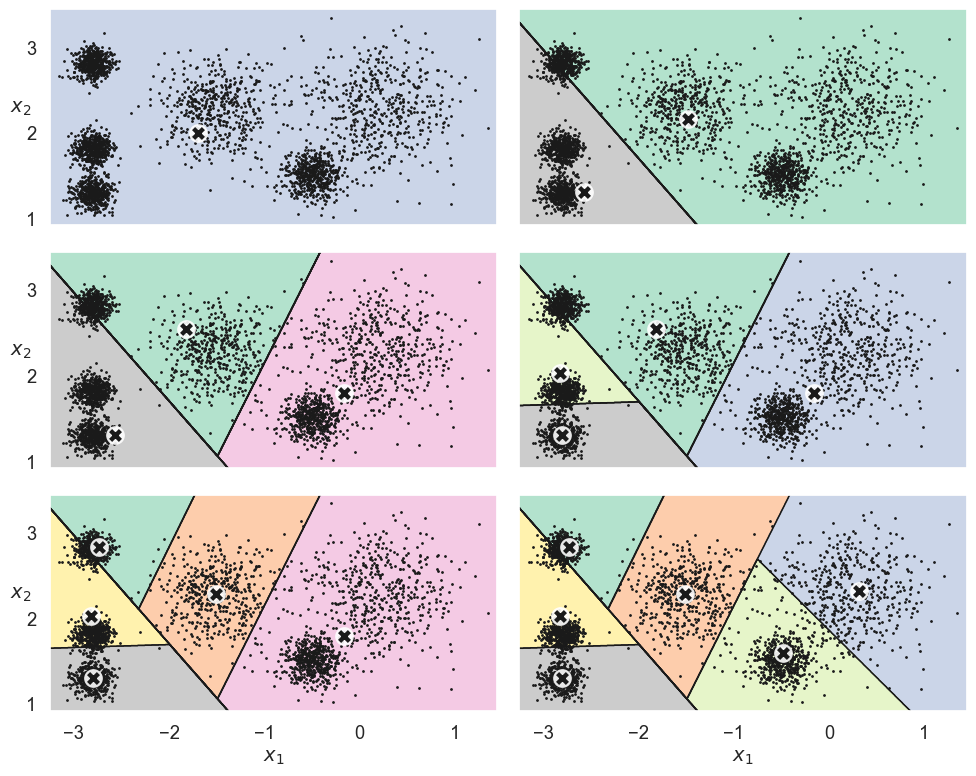

In [21]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_decision_boundaries(bisect_kmeans_iter1, X, show_xlabels=False)
#plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(bisect_kmeans_iter2, X, show_xlabels=False, show_ylabels=False)
#plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(bisect_kmeans_iter3, X, show_xlabels=False)

plt.subplot(324)
plot_decision_boundaries(bisect_kmeans_iter4, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(bisect_kmeans_iter5, X)

plt.subplot(326)
plot_decision_boundaries(bisect_kmeans_iter6, X, show_ylabels=False)
save_fig("kmeans_algorithm_diagram")
plt.show()